# Configurable Spot-Perp Arbitrage Backtest

This notebook builds a spot-perpetual divergence backtest from cached parquet files. Change `TRADING_SYMBOL` in Cell 3 to switch the instrument. The notebook uses the first week of cached data to calibrate divergence thresholds and then trades only on the second week.

In [1]:
import json
import os
from pathlib import Path

import pandas as pd

from backtester.backtest_runner import Backtester
from backtester.exchange import Exchange, MarginAllocationType, MarketType, PositionSide
from backtester.market import Market, MarketDataFromCSV
from backtester.performance import PerformanceAnalyzer
from backtester.portfolio import Portfolio, WeightedStrategy
from backtester.strategies import AllocationPosition, CloseReason, Strategy

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

# Resolve data directory regardless of CWD (alphakit root or backtesting root)
_cwd = Path(os.getcwd())
_candidates = [
    _cwd / "notebooks" / "kraken" / "data",
    _cwd / "backtesting" / "notebooks" / "kraken" / "data",
]
data_dir = next((p for p in _candidates if p.exists()), _candidates[0])
data_dir.mkdir(parents=True, exist_ok=True)
print(f"data_dir: {data_dir}")

/Users/nick/Documents/www/alphakit


In [ ]:
# Kraken spot altname (e.g. XBTUSD, ETHUSD, SOLUSD) — set PERP_CACHE_SYMBOL to the
# matching PF_ futures symbol.  DATE_FROM / DATE_TO must match the window used
# when downloading data in kraken_arbitrage_test.ipynb.
SPOT_CACHE_SYMBOL  = "XBTUSD"        # Kraken spot altname used as the parquet key
PERP_CACHE_SYMBOL  = "PF_XBTUSD"     # Kraken Futures symbol used as the parquet key
PERP_MARKET_TYPE   = "usd_perpetual"
INTERVAL           = 1
UNIT_OF_TIME       = "minute"
DATE_FROM          = "2026-03-23 00:00:00"
DATE_TO            = "2026-04-06 00:00:00"
TRAIN_WINDOW_DAYS  = 7
ENTRY_THRESHOLD_QUANTILE = 0.90
EXIT_THRESHOLD_QUANTILE  = 0.35
STARTING_BALANCE_QUOTE   = 1_000.0


def split_kraken_spot_symbol(altname: str) -> tuple[str, str]:
    """Return (base, quote) for a Kraken spot altname like XBTUSD or ETHUSD."""
    for quote in ("USDT", "USDC", "USD", "BTC", "ETH"):
        if altname.endswith(quote):
            return altname[: -len(quote)], quote
    raise ValueError(f"Unrecognised quote asset in Kraken altname: {altname}")


def format_cache_timestamp(timestamp_text: str) -> str:
    return pd.Timestamp(timestamp_text, tz="UTC").strftime("%Y-%m-%dT%H-%M-%S+00-00")


BASE_ASSET, DATA_QUOTE_ASSET = split_kraken_spot_symbol(SPOT_CACHE_SYMBOL)
QUOTE = "USD"
SPOT_SYMBOL = f"{BASE_ASSET}_SPOT/{QUOTE}"
PERP_SYMBOL = f"{BASE_ASSET}_PERP/{QUOTE}"
CACHE_DATE_FROM = format_cache_timestamp(DATE_FROM)
CACHE_DATE_TO   = format_cache_timestamp(DATE_TO)

spot_parquet_path = data_dir / f"{SPOT_CACHE_SYMBOL}__spot__1m__{CACHE_DATE_FROM}__{CACHE_DATE_TO}.parquet"
perp_parquet_path = data_dir / f"{PERP_CACHE_SYMBOL}__{PERP_MARKET_TYPE}__1m__{CACHE_DATE_FROM}__{CACHE_DATE_TO}.parquet"
spot_csv_path = data_dir / f"{SPOT_CACHE_SYMBOL}_spot_1m.csv"
perp_csv_path = data_dir / f"{PERP_CACHE_SYMBOL}_perp_1m.csv"

if not spot_parquet_path.exists():
    raise FileNotFoundError(f"Spot parquet not found: {spot_parquet_path}")
if not perp_parquet_path.exists():
    raise FileNotFoundError(f"Perp parquet not found: {perp_parquet_path}")


def parquet_to_csv(parquet_path: Path, csv_path: Path) -> pd.DataFrame:
    frame = pd.read_parquet(parquet_path).copy()
    frame["timestamp"] = pd.to_datetime(frame["timestamp"], utc=True)
    frame = frame.sort_values("timestamp").reset_index(drop=True)
    frame.to_csv(csv_path, index=False)
    return frame


spot_raw = parquet_to_csv(spot_parquet_path, spot_csv_path)
perp_raw = parquet_to_csv(perp_parquet_path, perp_csv_path)

merged_raw = spot_raw.merge(
    perp_raw,
    on="timestamp",
    suffixes=("_spot", "_perp"),
    how="inner",
).sort_values("timestamp").reset_index(drop=True)

for column in ["open", "high", "low", "close"]:
    merged_raw[f"divergence_{column}_bps"] = (
        (merged_raw[f"{column}_perp"] - merged_raw[f"{column}_spot"])
        / merged_raw[f"{column}_spot"]
        * 10_000
    )

indicator_frame = pd.DataFrame(
    {
        "timestamp":    merged_raw["timestamp"],
        "divergence_bps": merged_raw["divergence_close_bps"],
        "spot_close":   merged_raw["close_spot"],
        "perp_close":   merged_raw["close_perp"],
        "spot_open":    merged_raw["open_spot"],
        "perp_open":    merged_raw["open_perp"],
    }
)

dataset_start        = indicator_frame["timestamp"].min()
train_end_exclusive  = dataset_start + pd.Timedelta(days=TRAIN_WINDOW_DAYS)
train_frame = indicator_frame.loc[indicator_frame["timestamp"] < train_end_exclusive].copy()
test_frame  = indicator_frame.loc[indicator_frame["timestamp"] >= train_end_exclusive].copy()

if train_frame.empty or test_frame.empty:
    raise ValueError("Dataset does not contain both a first-week training window and a second-week trading window.")

train_abs_divergence = train_frame["divergence_bps"].abs()
ENTRY_DIVERGENCE_BPS = float(train_abs_divergence.quantile(ENTRY_THRESHOLD_QUANTILE))
EXIT_DIVERGENCE_BPS  = float(train_abs_divergence.quantile(EXIT_THRESHOLD_QUANTILE))
EXIT_DIVERGENCE_BPS  = min(EXIT_DIVERGENCE_BPS, ENTRY_DIVERGENCE_BPS * 0.5)
EXIT_DIVERGENCE_BPS  = max(EXIT_DIVERGENCE_BPS, ENTRY_DIVERGENCE_BPS * 0.1)

TEST_DATE_FROM = test_frame["timestamp"].min().strftime("%Y-%m-%d %H:%M:%S")
TEST_DATE_TO   = test_frame["timestamp"].max().strftime("%Y-%m-%d %H:%M:%S")

calibration_summary = {
    "spot_cache_symbol":     SPOT_CACHE_SYMBOL,
    "perp_cache_symbol":     PERP_CACHE_SYMBOL,
    "dataset_start":         str(indicator_frame["timestamp"].min()),
    "dataset_end":           str(indicator_frame["timestamp"].max()),
    "train_rows":            int(len(train_frame)),
    "test_rows":             int(len(test_frame)),
    "entry_divergence_bps":  ENTRY_DIVERGENCE_BPS,
    "exit_divergence_bps":   EXIT_DIVERGENCE_BPS,
    "test_date_from":        TEST_DATE_FROM,
    "test_date_to":          TEST_DATE_TO,
}

print(f"Spot cache symbol : {SPOT_CACHE_SYMBOL}")
print(f"Perp cache symbol : {PERP_CACHE_SYMBOL}")
print(f"Entry divergence  : {ENTRY_DIVERGENCE_BPS:.4f} bps")
print(f"Exit divergence   : {EXIT_DIVERGENCE_BPS:.4f} bps")
print("Calibration summary", json.dumps(calibration_summary, indent=2, default=str))
display(train_frame[["timestamp", "divergence_bps"]].head())
display(test_frame[["timestamp", "divergence_bps"]].head())

In [3]:
market = Market()

spot_market = MarketDataFromCSV(
    symbol=SPOT_SYMBOL,
    date_from=TEST_DATE_FROM,
    date_to=TEST_DATE_TO,
    interval=INTERVAL,
    unit_of_time=UNIT_OF_TIME,
    path=str(spot_csv_path),
).get_df()

perp_market = MarketDataFromCSV(
    symbol=PERP_SYMBOL,
    date_from=TEST_DATE_FROM,
    date_to=TEST_DATE_TO,
    interval=INTERVAL,
    unit_of_time=UNIT_OF_TIME,
    path=str(perp_csv_path),
).get_df()

market.add_market(symbol=SPOT_SYMBOL, df=spot_market)
market.add_market(symbol=PERP_SYMBOL, df=perp_market)

indicator_market = test_frame.copy()
indicator_market["time_open"] = pd.to_datetime(indicator_market["timestamp"], utc=True).dt.tz_localize(None)
indicator_market["time_close"] = indicator_market["time_open"] + pd.Timedelta(minutes=INTERVAL) - pd.Timedelta(milliseconds=1)
indicator_market = indicator_market.set_index("time_close")
indicator_market = indicator_market.reindex(spot_market.index)

market.add_indicator(
    symbol=SPOT_SYMBOL,
    interval=INTERVAL,
    unit_of_time=UNIT_OF_TIME,
    indicator_name="divergence_bps",
    df=indicator_market["divergence_bps"],
)
market.add_indicator(
    symbol=PERP_SYMBOL,
    interval=INTERVAL,
    unit_of_time=UNIT_OF_TIME,
    indicator_name="divergence_bps",
    df=indicator_market["divergence_bps"],
)

market.compile()

print(f"Trading window: {TEST_DATE_FROM} -> {TEST_DATE_TO}")
print(f"Entry divergence learned from week one: {ENTRY_DIVERGENCE_BPS:.4f} bps")
print(f"Exit divergence learned from week one: {EXIT_DIVERGENCE_BPS:.4f} bps")
print(f"Spot rows: {len(spot_market):,}")
print(f"Perp rows: {len(perp_market):,}")
print(f"Compiled candles: {len(market.index_num_ts):,}")
display(indicator_market[["divergence_bps", "spot_close", "perp_close"]].head())

/Users/nick/Documents/www/alphakit/src/backtester/market.py:35: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  df["time"] = df["time"].view("int64") // 10**9
/Users/nick/Documents/www/alphakit/src/backtester/market.py:38: FutureWarning: 'T' is deprecated and will be removed in a future version. Please use 'min' instead of 'T'.
  df["time_close"] = df["time_open"] + pd.Timedelta(timedelta) - pd.Timedelta("1ms")
/Users/nick/Documents/www/alphakit/src/backtester/market.py:42: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df = df.resample(timedelta).agg(
/Users/nick/Documents/www/alphakit/src/backtester/market.py:55: FutureWarning: 'T' is deprecated and will be removed in a future version. Please use 'min' instead of 'T'.
  df["time_close"] = df["time_open"] + pd.Timedelta(timedelta) - pd.Timedelta("1ms")
/Users/nick/Documents/www/alphakit/src/b

Trading window: 2026-03-30 00:00:00 -> 2026-04-05 23:59:00
Entry divergence learned from week one: 113.6364 bps
Exit divergence learned from week one: 0.0000 bps
Spot rows: 10,079
Perp rows: 10,079
Compiled candles: 10,079


,divergence_bps,spot_close,perp_close
ts,,,
2026-03-30 00:00:59.999,-119.047619,0.0084,0.0083
2026-03-30 00:01:59.999,-119.047619,0.0084,0.0083
2026-03-30 00:02:59.999,-119.047619,0.0084,0.0083
2026-03-30 00:03:59.999,0.000000,0.0084,0.0084
2026-03-30 00:04:59.999,0.000000,0.0084,0.0084


In [ ]:
class DivergenceLegStrategy(Strategy):
    def __init__(  # noqa: PLR0913
        self,
        key: str,
        market: Market,
        symbol: str,
        side: PositionSide,
        divergence_indicator_key: str,
        entry_divergence_bps: float,
        exit_divergence_bps: float,
        position_percent: float,
    ):
        super().__init__(key, market, symbol)
        self.side = side
        self.divergence_indicator_key = divergence_indicator_key
        self.entry_divergence_bps = entry_divergence_bps
        self.exit_divergence_bps = exit_divergence_bps
        self.position_percent = position_percent

    def has_open_position(self) -> bool:
        return any(position.symbol == self.symbol for position in self.allocation.positions)

    def should_enter(self, divergence: float) -> bool:
        # Both legs enter on the same condition: perp premium over spot exceeds threshold.
        # The spot leg buys the cheap leg; the perp leg shorts the expensive leg.
        return divergence >= self.entry_divergence_bps

    def should_exit(self, divergence: float) -> bool:
        return abs(divergence) <= self.exit_divergence_bps

    def refresh(self):
        divergence = self.market.current[self.symbol]["indicators"].get(self.divergence_indicator_key)
        if pd.isna(divergence):
            return

        divergence = float(divergence)
        price = float(self.market.current[self.symbol]["close"])
        current_num = self.market.current["num"]
        is_last_candle = current_num == len(self.market.index_num_ts) - 1
        has_position = self.has_open_position()

        if (not has_position) and self.should_enter(divergence):
            self.allocation.positions = [
                AllocationPosition(
                    side=self.side,
                    symbol=self.symbol,
                    percent=self.position_percent,
                    average_open_price=price,
                )
            ]
            self.allocation.orders = []
            self._mark_allocation_changed()
            self.open_trade(side=self.side, open_price=price)
            return

        if has_position and (self.should_exit(divergence) or is_last_candle):
            self.allocation.positions = []
            self.allocation.orders = []
            self._mark_allocation_changed()
            self.close_trade(
                close_price=price,
                reason=CloseReason.convergence if self.should_exit(divergence) else CloseReason.end_of_test,
            )


LEG_ALLOCATION = 0.5
KRAKEN_SPOT_TAKER_FEE = 0.0026
KRAKEN_FUTURES_TAKER_FEE = 0.0005

exchange = Exchange(
    market=market,
    slippage=0.0005,
    maker_fee=KRAKEN_FUTURES_TAKER_FEE,
    taker_fee=KRAKEN_SPOT_TAKER_FEE,
    market_type=MarketType.future,
    max_leverage=2,
    margin_allocation_type=MarginAllocationType.cross,
)

portfolio = Portfolio(
    weighted_strategies=[
        WeightedStrategy(
            weight=1.0,
            strategy=DivergenceLegStrategy(
                key=f"{BASE_ASSET}_spot_long",
                market=market,
                symbol=SPOT_SYMBOL,
                side=PositionSide.long,
                divergence_indicator_key="divergence_bps",
                entry_divergence_bps=ENTRY_DIVERGENCE_BPS,
                exit_divergence_bps=EXIT_DIVERGENCE_BPS,
                position_percent=LEG_ALLOCATION,
            ),
        ),
        WeightedStrategy(
            weight=1.0,
            strategy=DivergenceLegStrategy(
                key=f"{BASE_ASSET}_perp_short",
                market=market,
                symbol=PERP_SYMBOL,
                side=PositionSide.short,
                divergence_indicator_key="divergence_bps",
                entry_divergence_bps=ENTRY_DIVERGENCE_BPS,
                exit_divergence_bps=EXIT_DIVERGENCE_BPS,
                position_percent=LEG_ALLOCATION,
            ),
        ),
    ],
    output_scale=1,
)

reporter = PerformanceAnalyzer(
    market=market,
    exchange=exchange,
    portfolio=portfolio,
    benchmark_symbols=[SPOT_SYMBOL, PERP_SYMBOL],
)

print(f"Portfolio, exchange, and reporter are ready for {TRADING_SYMBOL} with 50/50 spot and perp allocation.")
print(f"Spot taker fee    : {KRAKEN_SPOT_TAKER_FEE:.4%}")
print(f"Futures taker fee : {KRAKEN_FUTURES_TAKER_FEE:.4%}")


In [5]:
market.reset()
backtest = Backtester(market=market, portfolio=portfolio, exchange=exchange, reporter=reporter)
backtest.exchange.transactions.add_deposit(asset=QUOTE, volume=STARTING_BALANCE_QUOTE)
backtest.run_all()

report_df = backtest.reporter.merged.copy() if backtest.reporter.merged is not None else pd.DataFrame()
trade_df = pd.DataFrame([trade.__dict__ for trade in backtest.reporter.trades])

if not trade_df.empty:
    trade_df["holding_minutes"] = (
        pd.to_datetime(trade_df["time_close"]) - pd.to_datetime(trade_df["time_open"])
    ).dt.total_seconds() / 60
else:
    trade_df = pd.DataFrame(
        columns=[
            "symbol",
            "side",
            "time_open",
            "time_close",
            "open_price",
            "close_price",
            "close_reason",
            "profit",
            "loss",
            "pnl",
            "result",
            "holding_minutes",
        ]
    )

pair_trade_summary = {
    "trading_symbol": TRADING_SYMBOL,
    "closed_trades": int(len(trade_df)),
    "winner_trades": int((trade_df["pnl"] > 0).sum()) if not trade_df.empty else 0,
    "loser_trades": int((trade_df["pnl"] <= 0).sum()) if not trade_df.empty else 0,
    "avg_trade_pnl_ratio": float(trade_df["pnl"].mean()) if not trade_df.empty else 0.0,
    "median_trade_pnl_ratio": float(trade_df["pnl"].median()) if not trade_df.empty else 0.0,
    "avg_holding_minutes": float(trade_df["holding_minutes"].mean()) if not trade_df.empty else 0.0,
    "median_holding_minutes": float(trade_df["holding_minutes"].median()) if not trade_df.empty else 0.0,
}

print("Candles Processed:", backtest.market.current["num"])
print(
    f"Two-leg portfolio warning: this uses two signals in one portfolio with 50 percent long spot and 50 percent short perp for {TRADING_SYMBOL}, but the framework still treats both legs inside the generic exchange model, so treat reporter.summary as framework output rather than validated real-world arbitrage economics."
)
print("Pair trade summary", json.dumps(pair_trade_summary, sort_keys=True, indent=2, default=str))
print(f"Executed trades: {len(trade_df):,}")

if not trade_df.empty:
    display(
        trade_df[[
            "symbol",
            "side",
            "time_open",
            "time_close",
            "open_price",
            "close_price",
            "pnl",
            "holding_minutes",
            "close_reason",
            "result",
        ]].head(20)
    )

if not report_df.empty:
    print("Reporter summary", json.dumps(backtest.reporter.summary, sort_keys=True, indent=2, default=str))
    display(report_df.tail())

Candles Processed: 10078
Two-leg portfolio warning: this uses two signals in one portfolio with 50 percent long spot and 50 percent short perp for ATAUSDT, but the framework still treats both legs inside the generic exchange model, so treat reporter.summary as framework output rather than validated real-world arbitrage economics.
Pair trade summary {
  "avg_holding_minutes": 2.401937046004843,
  "avg_trade_pnl_ratio": 0.006065007462107676,
  "closed_trades": 1652,
  "loser_trades": 807,
  "median_holding_minutes": 2.0,
  "median_trade_pnl_ratio": 0.011235955056179803,
  "trading_symbol": "ATAUSDT",
  "winner_trades": 845
}
Executed trades: 1,652


,symbol,side,time_open,time_close,open_price,close_price,pnl,holding_minutes,close_reason,result
0,ATA_SPOT/USD,PositionSide.long,2026-03-30 00:07:59.999,2026-03-30 00:09:59.999,0.0083,0.0083,0.000000,2.0,CloseReason.convergence,TradeResult.loser
1,ATA_SPOT/USD,PositionSide.long,2026-03-30 00:11:59.999,2026-03-30 00:12:59.999,0.0084,0.0084,0.000000,1.0,CloseReason.convergence,TradeResult.loser
2,ATA_SPOT/USD,PositionSide.long,2026-03-30 00:25:59.999,2026-03-30 00:26:59.999,0.0085,0.0086,0.011765,1.0,CloseReason.convergence,TradeResult.winner
3,ATA_SPOT/USD,PositionSide.long,2026-03-30 00:31:59.999,2026-03-30 00:33:59.999,0.0086,0.0086,0.000000,2.0,CloseReason.convergence,TradeResult.loser
4,ATA_SPOT/USD,PositionSide.long,2026-03-30 00:42:59.999,2026-03-30 00:43:59.999,0.0085,0.0085,0.000000,1.0,CloseReason.convergence,TradeResult.loser
5,ATA_SPOT/USD,PositionSide.long,2026-03-30 00:44:59.999,2026-03-30 00:45:59.999,0.0085,0.0085,0.000000,1.0,CloseReason.convergence,TradeResult.loser
6,ATA_SPOT/USD,PositionSide.long,2026-03-30 00:51:59.999,2026-03-30 00:52:59.999,0.0085,0.0085,0.000000,1.0,CloseReason.convergence,TradeResult.loser
7,ATA_SPOT/USD,PositionSide.long,2026-03-30 00:53:59.999,2026-03-30 00:54:59.999,0.0085,0.0085,0.000000,1.0,CloseReason.convergence,TradeResult.loser
8,ATA_SPOT/USD,PositionSide.long,2026-03-30 00:56:59.999,2026-03-30 00:57:59.999,0.0085,0.0085,0.000000,1.0,CloseReason.convergence,TradeResult.loser
9,ATA_SPOT/USD,PositionSide.long,2026-03-30 01:04:59.999,2026-03-30 01:05:59.999,0.0085,0.0085,0.000000,1.0,CloseReason.convergence,TradeResult.loser


Reporter summary {
  "ATA_PERP/USD": {
    "gross_return": 102.32558139534885,
    "max_drawdown": -3.5294,
    "net_return": 2.3255813953488413,
    "sharpe_ratio": 2.1145213078185114
  },
  "ATA_SPOT/USD": {
    "gross_return": 103.5294117647059,
    "max_drawdown": -3.5294,
    "net_return": 3.529411764705892,
    "sharpe_ratio": 2.9951858811483807
  },
  "algo": {
    "closed_trades": 1652,
    "gross_return": 1269.8043134213237,
    "loser_trades": 807,
    "max_drawdown": -0.0,
    "net_return": 1169.8043134213237,
    "profit_factor": 842.628955501761,
    "sharpe_ratio": 24.236546453075793,
    "winner_trades": 845
  }
}


,time_open,time_close,algo__simple_returns,algo__log_returns,algo__cumulative_returns,algo__drawdown,algo__exchange_long_exposure,algo__exchange_short_exposure,algo__exchange_net_exposure,algo__exchange_gross_exposure,algo__portfolio_long_exposure,algo__portfolio_short_exposure,algo__portfolio_net_exposure,algo__portfolio_gross_exposure,ATA_SPOT/USD__simple_returns,ATA_SPOT/USD__log_returns,ATA_SPOT/USD__cumulative_returns,ATA_SPOT/USD__drawdown,ATA_PERP/USD__simple_returns,ATA_PERP/USD__log_returns,ATA_PERP/USD__cumulative_returns,ATA_PERP/USD__drawdown
ts,,,,,,,,,,,,,,,,,,,,,,
2026-04-01,2026-04-01,2026-04-01 23:59:59.999,0.991712,0.688995,2.768395,-0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.035294,-0.035932,0.964706,-0.035294,-0.035294,-0.035932,0.953488,-0.035294
2026-04-02,2026-04-02,2026-04-02 23:59:59.999,1.247517,0.809826,6.222017,-0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.073171,0.070618,1.035294,-0.000000,0.073171,0.070618,1.023256,-0.000000
2026-04-03,2026-04-03,2026-04-03 23:59:59.999,0.228826,0.206059,7.645774,-0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.034091,0.033523,1.070588,-0.000000,0.022727,0.022473,1.046512,-0.000000
2026-04-04,2026-04-04,2026-04-04 23:59:59.999,0.055935,0.054427,8.073439,-0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,1.070588,-0.000000,0.011111,0.011050,1.058140,-0.000000
2026-04-05,2026-04-05,2026-04-05 23:58:59.999,0.572817,0.452868,12.698043,-0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.032967,-0.033523,1.035294,-0.032967,-0.032967,-0.033523,1.023256,-0.032967


,time,message
1633,2026-04-05 23:18:59.999,Rebalanced: Portfolio Exposure 1.0 | Exchange ...
1634,2026-04-05 23:19:59.999,Rebalanced: Portfolio Exposure 0.0 | Exchange ...
1635,2026-04-05 23:20:59.999,Rebalanced: Portfolio Exposure 1.0 | Exchange ...
1636,2026-04-05 23:28:59.999,Rebalanced: Portfolio Exposure 0.0 | Exchange ...
1637,2026-04-05 23:30:59.999,Rebalanced: Portfolio Exposure 1.0 | Exchange ...
1638,2026-04-05 23:31:59.999,Rebalanced: Portfolio Exposure 0.0 | Exchange ...
1639,2026-04-05 23:33:59.999,Rebalanced: Portfolio Exposure 1.0 | Exchange ...
1640,2026-04-05 23:40:59.999,Rebalanced: Portfolio Exposure 0.0 | Exchange ...
1641,2026-04-05 23:43:59.999,Rebalanced: Portfolio Exposure 1.0 | Exchange ...
1642,2026-04-05 23:44:59.999,Rebalanced: Portfolio Exposure 0.0 | Exchange ...


,divergence_bps,spot_close,perp_close,pair_entry_signal,pair_exit_signal
ts,,,,,
2026-03-30 00:00:59.999,-119.047619,0.0084,0.0083,False,False
2026-03-30 00:01:59.999,-119.047619,0.0084,0.0083,False,False
2026-03-30 00:02:59.999,-119.047619,0.0084,0.0083,False,False
2026-03-30 00:03:59.999,0.000000,0.0084,0.0084,False,True
2026-03-30 00:04:59.999,0.000000,0.0084,0.0084,False,True
2026-03-30 00:05:59.999,0.000000,0.0084,0.0084,False,True
2026-03-30 00:06:59.999,0.000000,0.0084,0.0084,False,True
2026-03-30 00:07:59.999,120.481928,0.0083,0.0084,True,False
2026-03-30 00:08:59.999,120.481928,0.0083,0.0084,True,False


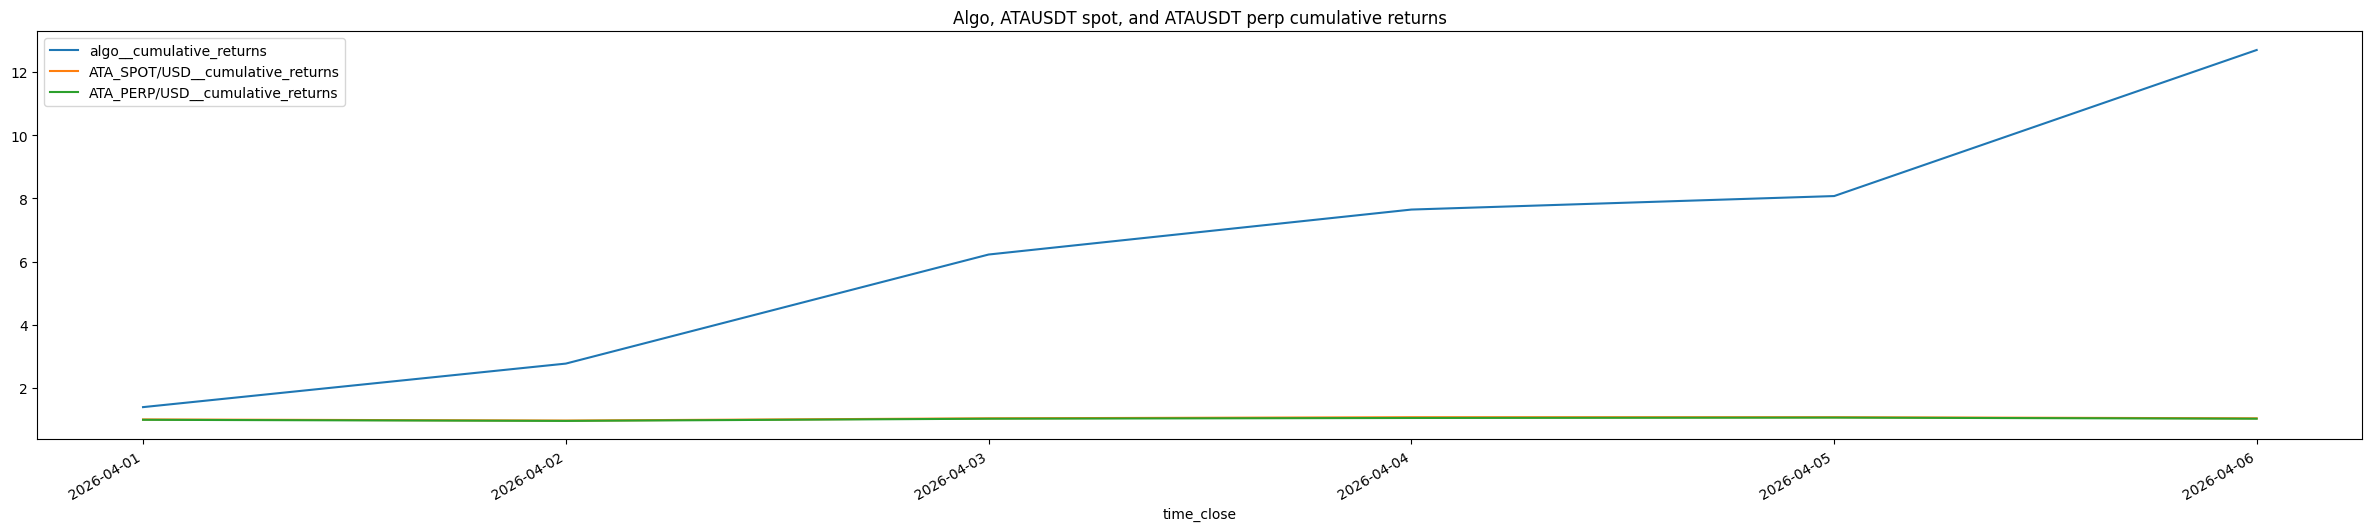

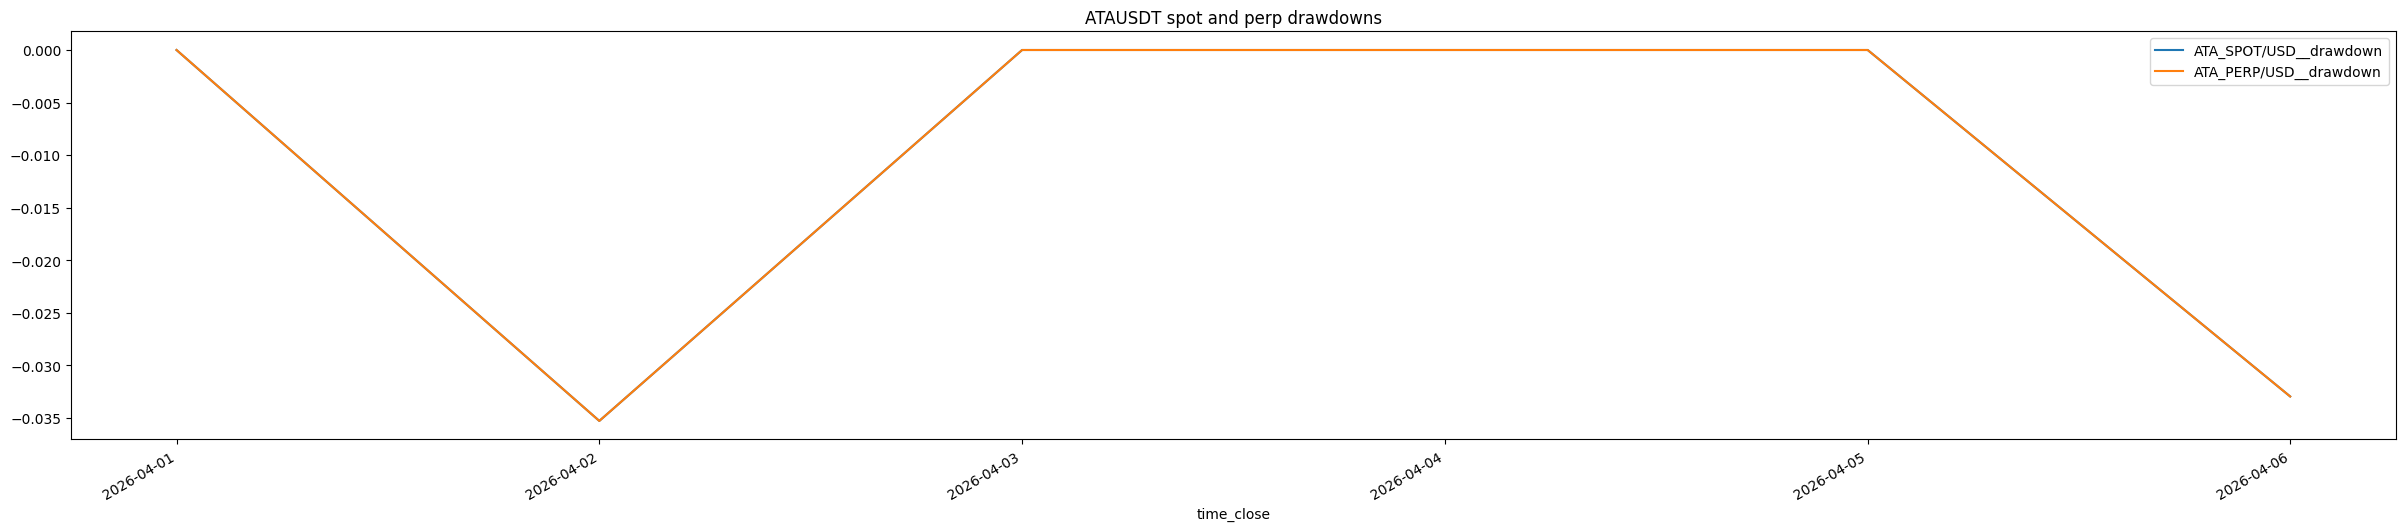

In [6]:
if not report_df.empty:
    report_df.plot(
        x="time_close",
        y=[
            "algo__cumulative_returns",
            f"{SPOT_SYMBOL}__cumulative_returns",
            f"{PERP_SYMBOL}__cumulative_returns",
        ],
        figsize=(30, 6),
        title=f"Algo, {TRADING_SYMBOL} spot, and {TRADING_SYMBOL} perp cumulative returns",
    )
    report_df.plot(
        x="time_close",
        y=[f"{SPOT_SYMBOL}__drawdown", f"{PERP_SYMBOL}__drawdown"],
        figsize=(30, 6),
        title=f"{TRADING_SYMBOL} spot and perp drawdowns",
    )

exchange_logs_df = pd.DataFrame(backtest.exchange.get_logs())
if not exchange_logs_df.empty:
    display(exchange_logs_df.tail(20))

spread_analysis = indicator_market[["divergence_bps", "spot_close", "perp_close"]].copy()
# Both legs enter on the same condition (perp premium); spot goes long, perp goes short.
spread_analysis["pair_entry_signal"] = spread_analysis["divergence_bps"] >= ENTRY_DIVERGENCE_BPS
spread_analysis["pair_exit_signal"] = spread_analysis["divergence_bps"].abs() <= EXIT_DIVERGENCE_BPS
display(spread_analysis.head(20))
